In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Future Interns ML Task 1 Started")

Future Interns ML Task 1 Started


In [11]:
import pandas as pd

data = pd.read_csv("./train.csv")

print(data.head())

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
1       2  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
2       3  CA-2017-138688  12/06/2017  16/06/2017    Second Class    DV-13045   
3       4  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   
4       5  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   

   Postal Code Region       Product ID         Cat

In [12]:
print(data.shape)
print(data.columns)
print(data.isnull().sum())

(9800, 18)
Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='str')
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64


In [24]:
data["Postal Code"] = data["Postal Code"].fillna(0)

In [26]:
data["Order Date"] = pd.to_datetime(data["Order Date"], dayfirst=True)

In [27]:
print(data.info())

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   str           
 2   Order Date     9800 non-null   datetime64[us]
 3   Ship Date      9800 non-null   str           
 4   Ship Mode      9800 non-null   str           
 5   Customer ID    9800 non-null   str           
 6   Customer Name  9800 non-null   str           
 7   Segment        9800 non-null   str           
 8   Country        9800 non-null   str           
 9   City           9800 non-null   str           
 10  State          9800 non-null   str           
 11  Postal Code    9800 non-null   float64       
 12  Region         9800 non-null   str           
 13  Product ID     9800 non-null   str           
 14  Category       9800 non-null   str           
 15  Sub-Category   9800 non-null   s

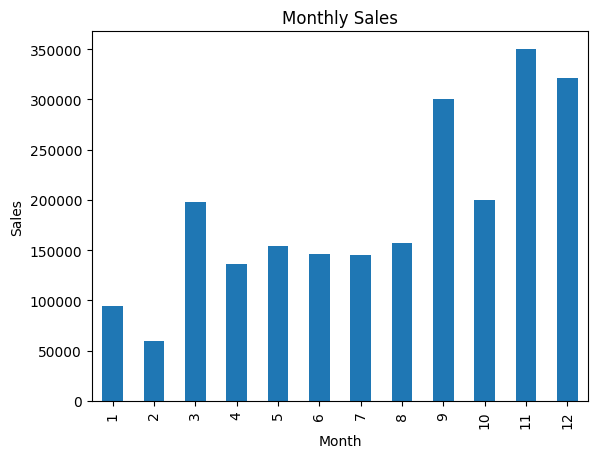

In [28]:
import matplotlib.pyplot as plt

monthly_sales = data.groupby(data["Order Date"].dt.month)["Sales"].sum()

monthly_sales.plot(kind="bar")

plt.title("Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.show()

In [29]:
monthly_data = data.groupby(data["Order Date"].dt.month)["Sales"].sum().reset_index()

print(monthly_data)

    Order Date        Sales
0            1   94291.6296
1            2   59371.1154
2            3  197573.5872
3            4  136283.0006
4            5  154086.7237
5            6  145837.5233
6            7  145535.6890
7            8  157315.9270
8            9  300103.4117
9           10  199496.2947
10          11  350161.7110
11          12  321480.1695


In [30]:
X = monthly_data[["Order Date"]]
y = monthly_data["Sales"]

In [31]:
from sklearn.linear_model import LinearRegression

In [32]:
model = LinearRegression()

model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [33]:
predictions = model.predict(X)

print(predictions)

[ 73881.85850256  94714.50214907 115547.14579557 136379.78944207
 157212.43308858 178045.07673508 198877.72038159 219710.36402809
 240543.00767459 261375.6513211  282208.2949676  303040.9386141 ]


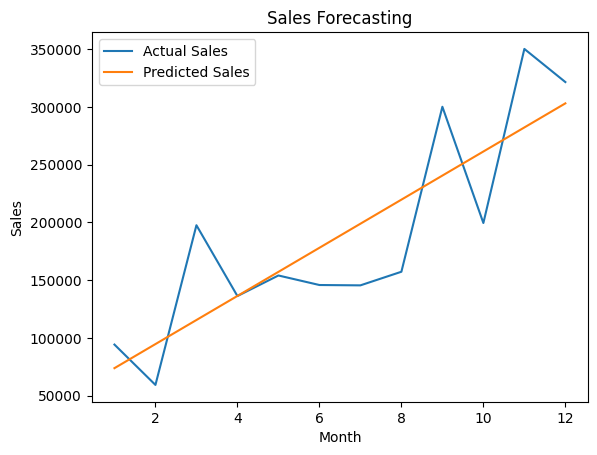

In [34]:
plt.plot(X, y, label="Actual Sales")
plt.plot(X, predictions, label="Predicted Sales")

plt.xlabel("Month")
plt.ylabel("Sales")
plt.title("Sales Forecasting")

plt.legend()

plt.show()

In [ ]:
S